In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset and synthesize dates
df = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df = df.rename(columns={'customerID': 'user_id', 'MonthlyCharges': 'monthly_spend'})

mock_today = pd.to_datetime('2024-01-01')
tenure_days = df['tenure'] * 30.436875
df['signup_date'] = mock_today - pd.to_timedelta(tenure_days, unit='D')
df['cancel_date'] = np.where(df['Churn'] == 'Yes', mock_today, pd.NaT)
df['last_active_date'] = mock_today
df = df.drop(columns=['tenure'])

# Right-censoring and tenure calculation
observation_date = df[['signup_date', 'cancel_date', 'last_active_date']].max().max()
df['effective_end_date'] = df['cancel_date'].fillna(observation_date)
df['tenure_months'] = (df['effective_end_date'] - df['signup_date']).dt.days / 30.436875

In [2]:
# 1. Assign each user to a cohort based on their signup month
df['cohort_month'] = df['signup_date'].dt.to_period('M')

# 2. Reconstruct user activity by month
# We expand the dataset so each user has a row for every month they remained active
records = []
for _, row in df.iterrows():
    cohort = row['cohort_month']
    user = row['user_id']
    max_active_month = int(np.floor(row['tenure_months']))
    
    # User is active from month 0 up to their max_active_month
    for month_index in range(max_active_month + 1):
        records.append({
            'cohort_month': cohort,
            'month_index': month_index,
            'user_id': user
        })

activity_df = pd.DataFrame(records)

print(f"Expanded activity shape: {activity_df.shape}")
display(activity_df.head())

Expanded activity shape: (228001, 3)


,cohort_month,month_index,user_id
0,2023-12,0,7590-VHVEG
1,2021-03,0,5575-GNVDE
2,2021-03,1,5575-GNVDE
3,2021-03,2,5575-GNVDE
4,2021-03,3,5575-GNVDE


In [3]:
# 3. Group by cohort and month_index to count unique active users
cohort_counts = activity_df.groupby(['cohort_month', 'month_index'])['user_id'].nunique().reset_index()

# 4. Pivot into a matrix (Rows: Cohort Month, Columns: Month Index)[cite: 1]
cohort_matrix = cohort_counts.pivot(index='cohort_month', columns='month_index', values='user_id')

# 5. Calculate retention percentages
# Divide all values in the row by the value at month 0 (the initial cohort size)
cohort_sizes = cohort_matrix.iloc[:, 0]
retention_matrix = cohort_matrix.divide(cohort_sizes, axis=0)

# Display the top left corner of the percentage matrix
display(retention_matrix.iloc[:10, :10].round(3))

month_index,0,1,2,3,4,5,6,7,8,9
cohort_month,,,,,,,,,,
2017-12,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2018-01,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2018-03,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2018-04,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2018-05,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2018-06,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2018-07,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2018-08,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2018-09,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


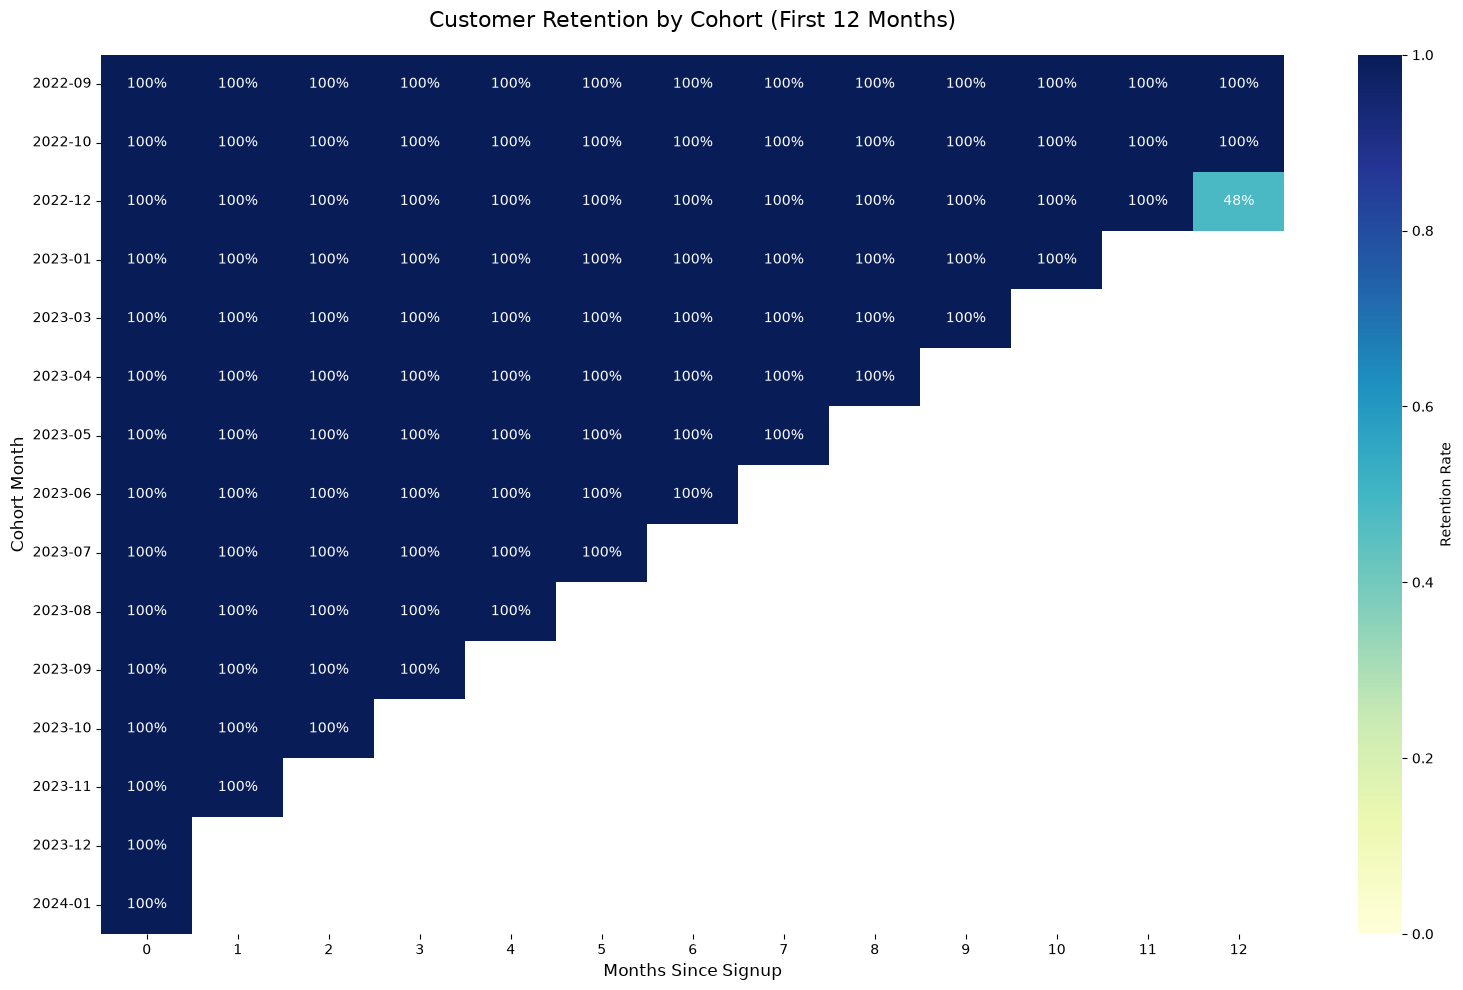

In [4]:
# Select a subset for visualization (e.g., the last 15 cohorts, first 12 months of retention)
recent_cohorts = retention_matrix.index[-15:]
plot_matrix = retention_matrix.loc[recent_cohorts, :12]

# Plot the heatmap
plt.figure(figsize=(16, 10))
plt.title('Customer Retention by Cohort (First 12 Months)', fontsize=16, pad=20)

sns.heatmap(
    plot_matrix, 
    annot=True,          # Show the percentage values
    fmt='.0%',           # Format as percentage
    cmap='YlGnBu',       # Yellow to Blue color scale
    vmin=0.0,            # Anchor scale at 0%
    vmax=1.0,            # Anchor scale at 100%
    cbar_kws={'label': 'Retention Rate'}
)

plt.xlabel('Months Since Signup', fontsize=12)
plt.ylabel('Cohort Month', fontsize=12)
plt.yticks(rotation=0)
plt.tight_layout()

plt.show()